In [1]:
import pandas as pd
import numpy as np

In [2]:
#loading data
credit_df = pd.read_csv('messy_kenyan_fintech_data.csv')

In [3]:
credit_df.head()

,Customer_ID,Age,Years_in_Business,Monthly_MPesa_Inflow,Airtime_Spend,Loan_Amount_Requested,Default_Status,Region
0,1001,69.0,10,49953.0,640.0,50000,1,mombasa
1,1002,32.0,5,20424.0,NaN,KES 2000,0,Nairobi
2,1003,78.0,1,37600.0,849.0,KES 5000,1,nairobi
3,1004,38.0,4,NaN,686.0,50000,1,nairobi
4,1005,41.0,9,NaN,453.0,50000,1,nairobi


In [4]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            1020 non-null   int64  
 1   Age                    920 non-null    float64
 2   Years_in_Business      1020 non-null   int64  
 3   Monthly_MPesa_Inflow   918 non-null    float64
 4   Airtime_Spend          917 non-null    float64
 5   Loan_Amount_Requested  1020 non-null   object 
 6   Default_Status         1020 non-null   int64  
 7   Region                 1020 non-null   object 
dtypes: float64(3), int64(3), object(2)
memory usage: 63.9+ KB


## Data quality audit

In [5]:
#check duplicates
credit_df.duplicated().sum()

np.int64(3)

There are 3 duplicates in our data

In [6]:
#handling duplicates
credit_df.drop_duplicates()

,Customer_ID,Age,Years_in_Business,Monthly_MPesa_Inflow,Airtime_Spend,Loan_Amount_Requested,Default_Status,Region
0,1001,69.0,10,49953.0,640.0,50000,1,mombasa
1,1002,32.0,5,20424.0,NaN,KES 2000,0,Nairobi
2,1003,78.0,1,37600.0,849.0,KES 5000,1,nairobi
3,1004,38.0,4,NaN,686.0,50000,1,nairobi
4,1005,41.0,9,NaN,453.0,50000,1,nairobi
...,...,...,...,...,...,...,...,...
1014,1015,38.0,11,13969.0,386.0,2000,0,Mombasa
1015,1016,50.0,6,17195.0,136.0,5000,1,Mombasa
1016,1017,75.0,4,24616.0,554.0,KES 5000,0,mombasa
1017,1018,39.0,9,64735.0,118.0,2000,1,nairobi


In [7]:
#check missing values
credit_df.isnull().sum()

Customer_ID                0
Age                      100
Years_in_Business          0
Monthly_MPesa_Inflow     102
Airtime_Spend            103
Loan_Amount_Requested      0
Default_Status             0
Region                     0
dtype: int64

In [8]:
#standardization of categorical data
credit_df['Region'].value_counts()

Region
Nairobi    180
mombasa    171
Mombasa    170
NRB        169
MSA        166
nairobi    164
Name: count, dtype: int64

In [9]:
credit_df['Region'] = credit_df['Region']. replace({'nairobi': 'Nairobi', 'NRB': 'Nairobi', 'mombasa': 'Mombasa', 'MSA': 'Mombasa'})

### Outliers treatment

In [10]:
credit_df

,Customer_ID,Age,Years_in_Business,Monthly_MPesa_Inflow,Airtime_Spend,Loan_Amount_Requested,Default_Status,Region
0,1001,69.0,10,49953.0,640.0,50000,1,Mombasa
1,1002,32.0,5,20424.0,NaN,KES 2000,0,Nairobi
2,1003,78.0,1,37600.0,849.0,KES 5000,1,Nairobi
3,1004,38.0,4,NaN,686.0,50000,1,Nairobi
4,1005,41.0,9,NaN,453.0,50000,1,Nairobi
...,...,...,...,...,...,...,...,...
1015,1016,50.0,6,17195.0,136.0,5000,1,Mombasa
1016,1017,75.0,4,24616.0,554.0,KES 5000,0,Mombasa
1017,1018,39.0,9,64735.0,118.0,2000,1,Nairobi
1018,1019,66.0,5,3701.0,486.0,2000,1,Mombasa


In [11]:
#checking outliers
credit_df.describe()

,Customer_ID,Age,Years_in_Business,Monthly_MPesa_Inflow,Airtime_Spend,Default_Status
count,1020.000000,920.000000,1020.000000,9.180000e+02,917.000000,1020.000000
mean,1490.892157,50.489130,7.063725,3.949029e+04,496.006543,0.510784
std,293.939033,20.141985,4.337894,2.327520e+05,202.252690,0.500129
min,1001.000000,-25.000000,0.000000,4.110000e+02,-86.000000,0.000000
25%,1235.750000,33.000000,3.000000,1.374800e+04,353.000000,0.000000
50%,1490.500000,50.000000,7.000000,2.461600e+04,498.000000,1.000000
75%,1745.250000,68.000000,11.000000,3.909950e+04,636.000000,1.000000
max,2000.000000,84.000000,14.000000,5.000000e+06,1149.000000,1.000000


In [12]:
#fixing logical outliers(negative values in age and aitrime spend )
credit_df = credit_df [(credit_df ['Age'] >= 18) & (credit_df ['Airtime_Spend'] > 0)]


Dropped age values less than 18 years because thats mainly the age limit for an individual to borrow or have acess to loans and financial services and also the negative values in the airtime spend column. we can't have negative values of airtime spend because its either the customer spent airtime or did not.

### Handling missing values

In [13]:
credit_df.isnull().sum()

Customer_ID               0
Age                       0
Years_in_Business         0
Monthly_MPesa_Inflow     83
Airtime_Spend             0
Loan_Amount_Requested     0
Default_Status            0
Region                    0
dtype: int64

In [14]:
#checking data skewness on the monthly mpesa inflow column
credit_df['Monthly_MPesa_Inflow'].skew()

np.float64(1.2037006949460485)

The data in the monthly mpesa inflow is strongly right skewed

In [15]:
#filling monthly mpesa inflow with median
credit_df['Monthly_MPesa_Inflow'] = credit_df['Monthly_MPesa_Inflow'].fillna(credit_df['Monthly_MPesa_Inflow'].median())

/tmp/ipykernel_825/2336439512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  credit_df['Monthly_MPesa_Inflow'] = credit_df['Monthly_MPesa_Inflow'].fillna(credit_df['Monthly_MPesa_Inflow'].median())


The monthly mpesa inflow was filled with median because the data distribution was positively skewed. since mean is sensitive to outliers using it to impute missing values would bias the data. median is more robust and better represents positively skewed data

In [16]:
#confirming no missing values
credit_df.isnull().sum()

Customer_ID              0
Age                      0
Years_in_Business        0
Monthly_MPesa_Inflow     0
Airtime_Spend            0
Loan_Amount_Requested    0
Default_Status           0
Region                   0
dtype: int64

In [17]:
#checking if region column is clean
credit_df['Region'].value_counts()

Region
Mombasa    412
Nairobi    411
Name: count, dtype: int64

In [18]:
#saving the cleaned data
credit_df.to_csv('clean_kenyan_fintech_data.csv')

### Exploratory Data Analysis

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
sns.set_theme( style = 'whitegrid')

/tmp/ipykernel_825/1543140630.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = credit_df, x = 'Default_Status', palette= 'viridis')


Text(0.5, 1.0, 'Overall Default Distribution  (0 = Paid, 1 = Defaulted)')

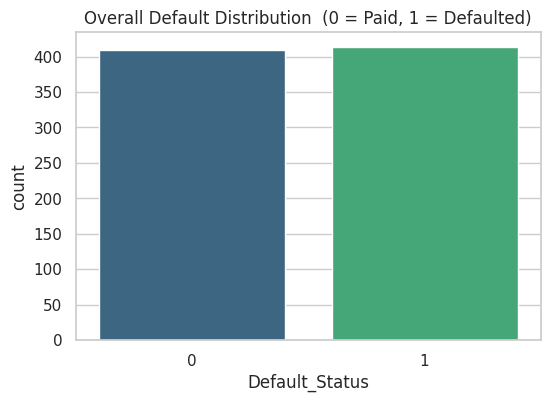

In [21]:
#distribution of defaults
plt.figure(figsize = (6,4))
sns.countplot(data = credit_df, x = 'Default_Status', palette= 'viridis')
plt.title('Overall Default Distribution  (0 = Paid, 1 = Defaulted)')

/tmp/ipykernel_825/3421168170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = credit_df, x = 'Default_Status', y = 'Airtime_Spend',palette= 'Set2')


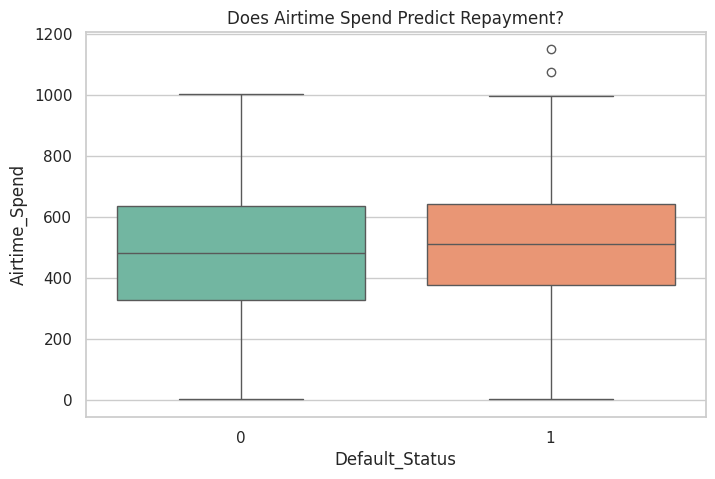

In [22]:
plt.figure(figsize = (8,5))
sns.boxplot(data = credit_df, x = 'Default_Status', y = 'Airtime_Spend',palette= 'Set2')
plt.title('Does Airtime Spend Predict Repayment?')
plt.show()
          

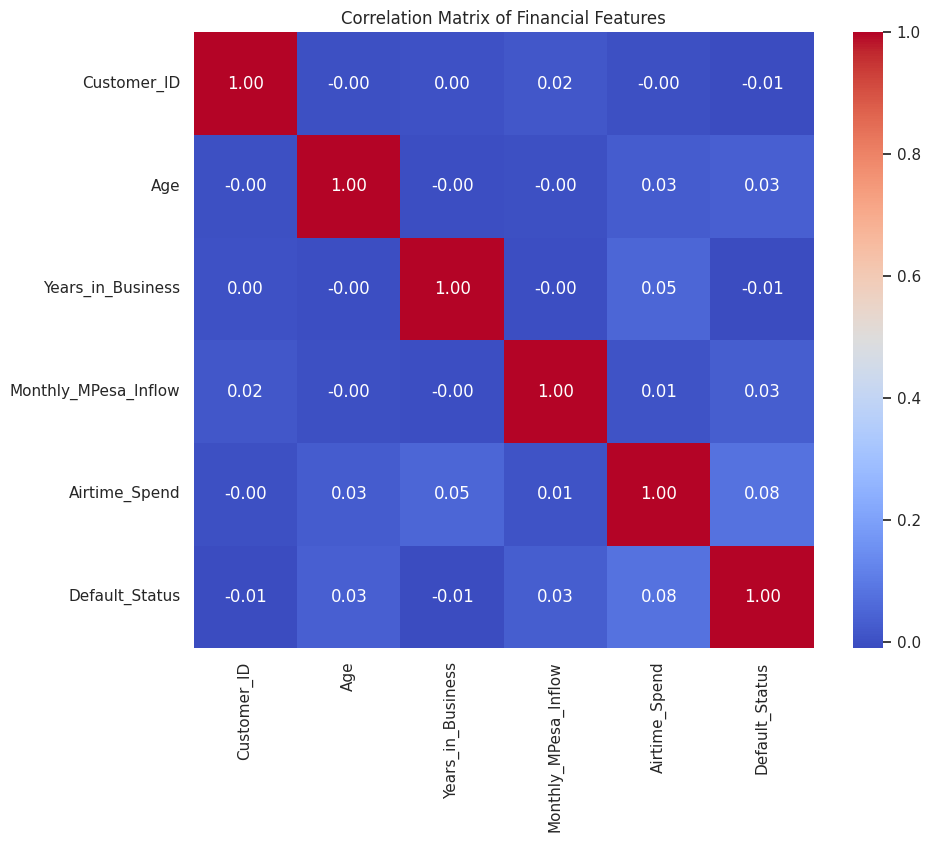

In [23]:
#correlation heatmap
plt.figure(figsize=(10,8))
corr = credit_df.corr(numeric_only= True)
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix of Financial Features')
plt.show()

CREDIT SCORE MODELLING

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [26]:
#preparing features(X) and target variable(y)
X = credit_df.drop(['Default_Status', 'Region', 'Customer_ID'], axis = 1, errors = 'ignore')
y = credit_df['Default_Status']

In [27]:
#encoding categorical values(region)
X = pd.get_dummies(X, drop_first=True)

In [28]:
#data splitting
#training (80%) and testing(20%)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [29]:
#model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
#predicting
y_pred = model.predict(X_test)

In [31]:
#model evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.62      0.59        89
           1       0.51      0.46      0.48        76

    accuracy                           0.55       165
   macro avg       0.54      0.54      0.54       165
weighted avg       0.54      0.55      0.54       165

